# MMS sin(k pi x) sin(k pi y) with hard-curl PINN flux reconstruction, Q1 CG

This notebook is the MMS counterpart of the SPE10 hard-curl notebook.  The pressure problem is solved on the same 64 x 64 primal mesh, while transport uses the associated 65 x 65 nodal-dual mesh.  The hard-curl reconstruction keeps the same structure:

\[
  \mathbf q_\theta = \mathbf q_p + \nabla^\perp \psi_\theta,
  \qquad \nabla^\perp\psi=(\partial_y\psi,-\partial_x\psi),
\]

and is trained on integrated CG fluxes over the Deng dual faces.  The 512-reference, SPE10, wells, and CVFEM/MRST oracle machinery from the source notebook are intentionally removed.  Optional MRST saturation comparison is loaded only if a matching `*_mms_k{k}.mat` file is present.


In [1]:
import pathlib
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve
from scipy.io import loadmat

try:
    import torch
    import torch.nn as nn
    from tqdm.auto import tqdm
    TORCH_AVAILABLE = True
except ModuleNotFoundError:
    torch = None
    nn = None
    TORCH_AVAILABLE = False
    def tqdm(iterable, **kwargs):
        return iterable

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

np.random.seed(1234)
if TORCH_AVAILABLE:
    torch.manual_seed(1234)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
else:
    device = "numpy"

# Single MMS parameter.  Do not hard-code k downstream.
MMS_K = 3
A_WAVE = float(MMS_K) * np.pi

# Mesh and transport controls.
NX = NY = 64
xmin = ymin = 0.0
xmax = ymax = 1.0
hx = (xmax - xmin) / NX
hy = (ymax - ymin) / NY
h_est = min(hx, hy)
PHI_MATRIX = 1.0
CFL = 0.45
FPRIME_MAX = 2.0
SOURCE_SATURATION = 1.0
BOUNDARY_INFLOW_S = 0.0
TRANSPORT_T_VALUES = np.array([0.005, 0.01, 0.02], dtype=float)
TRANSPORT_CASE_KEY = "T0.05"
TRANSPORT_CLIP = True
TRANSPORT_USE_FIXED_DT = False
TRANSPORT_DT = 1.0e-4

# Training controls: same protocol as the hard-curl SPE10 notebook.
ENABLE_HARD_CURL_PINN = True
HARD_PINN_LOAD_CHECKPOINT = True
HARD_PINN_EPOCHS = 5000
HARD_PINN_LR = 2.0e-3
HARD_PINN_HIDDEN_DIM = 96
HARD_PINN_DEPTH = 4
HARD_PINN_FOURIER_FREQS = np.array([1, 2, 4, 8, 16, 32], dtype=float)
HARD_PINN_USE_LOGK = True  # kappa=1 -> constant zero log-k feature; kept for architecture parity.
HARD_PINN_USE_RELATIVE_WEIGHTS = False
HARD_PINN_LBFGS_POLISH = True
HARD_PINN_LBFGS_MAX_ITER = 300
HARD_PINN_LBFGS_HISTORY_SIZE = 50
HARD_PINN_LBFGS_TOL_GRAD = 1.0e-10
HARD_PINN_LBFGS_TOL_CHANGE = 1.0e-12
HARD_PINN_LBFGS_PRINT_EVERY = 25
HARD_PINN_LBFGS_EARLY_STOP_PATIENCE = 75
HARD_PINN_LBFGS_MIN_DELTA = 1.0e-10
HARD_PINN_LBFGS_MIN_CALLS = 50
HARD_PINN_WEIGHT_CLIP_FACTOR = 30.0
HARD_PINN_QP_QUAD_ORDER = 128
HARD_PINN_QP_AUDIT_QUAD_ORDER = 256
HARD_PINN_PRINT_EVERY = max(1, HARD_PINN_EPOCHS // 10)
HARD_PINN_LINEAR_RIDGE = 1.0e-10
HARD_PINN_TORCH_DTYPE = torch.float32 if TORCH_AVAILABLE else None

# Rotated zeta conservation diagnostic controls.
CONSERVATION_EPS = 1.0e-16
CONSERVATION_RTAU_EDGE_NQ = 96
CONSERVATION_RZETA_EDGE_NQ = 24
CONSERVATION_RZETA_SOURCE_NQ = 24
CONSERVATION_RZETA_ANGLE_DEG = 45.0
CONSERVATION_RZETA_HU = 1.0 * h_est
CONSERVATION_RZETA_HV = 1.0 * h_est
CONSERVATION_RZETA_SHIFT_FRACTION = np.asarray((0.31, 0.47), dtype=float)
CONSERVATION_RZETA_MIN_AREA = 1.0e-14
CONSERVATION_RZETA_COLORBAR_MODE = "shared"
CONSERVATION_CMAP = "RdBu_r"

folder = pathlib.Path("fenicsx/code/fracture problem/case3_ecmor")
if not folder.exists():
    folder = pathlib.Path("case3_ecmor")
MMS_TAG = f"mms_k{int(MMS_K)}"
CHECKPOINT_PATH = folder / f"hardcurl_pinn_{MMS_TAG}_Q1_{NX}x{NY}.pt"

x_edges = np.linspace(xmin, xmax, NX + 1)
y_edges = np.linspace(ymin, ymax, NY + 1)
x_nodes = x_edges.copy()
y_nodes = y_edges.copy()
Xn, Yn = np.meshgrid(x_nodes, y_nodes, indexing="xy")
node_xy = np.column_stack([Xn.reshape(-1), Yn.reshape(-1)])
n_nodes = node_xy.shape[0]

def node_id(i, j):
    return int(j) * (NX + 1) + int(i)

cell_nodes = []
cell_bounds = []
cell_centers = []
for j in range(NY):
    for i in range(NX):
        cell_nodes.append([node_id(i, j), node_id(i + 1, j), node_id(i, j + 1), node_id(i + 1, j + 1)])
        x0, x1 = x_edges[i], x_edges[i + 1]
        y0, y1 = y_edges[j], y_edges[j + 1]
        cell_bounds.append((x0, x1, y0, y1))
        cell_centers.append((0.5 * (x0 + x1), 0.5 * (y0 + y1)))
cell_nodes = np.asarray(cell_nodes, dtype=np.int64)
cell_bounds = np.asarray(cell_bounds, dtype=float)
cell_centers = np.asarray(cell_centers, dtype=float)
ncell = NX * NY
cell_area = np.full(ncell, hx * hy, dtype=float)
cell_pv = PHI_MATRIX * cell_area
PV_matrix = PHI_MATRIX * (xmax - xmin) * (ymax - ymin)


def p_exact(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    return np.sin(A_WAVE * pts[:, 0]) * np.sin(A_WAVE * pts[:, 1])


def q_exact(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    x = pts[:, 0]
    y = pts[:, 1]
    return np.column_stack([
        -A_WAVE * np.cos(A_WAVE * x) * np.sin(A_WAVE * y),
        -A_WAVE * np.sin(A_WAVE * x) * np.cos(A_WAVE * y),
    ])


def f_exact(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    return 2.0 * A_WAVE ** 2 * np.sin(A_WAVE * pts[:, 0]) * np.sin(A_WAVE * pts[:, 1])


def source_integral_rect(x0, x1, y0, y1):
    return 2.0 * (np.cos(A_WAVE * x0) - np.cos(A_WAVE * x1)) * (np.cos(A_WAVE * y0) - np.cos(A_WAVE * y1))


def q_p_numpy(points):
    # A simple analytic particular flux with div(q_p)=f_exact.
    # It is not the Darcy flux and contains no pressure/permeability information.
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    x = pts[:, 0]
    y = pts[:, 1]
    return np.column_stack([
        2.0 * A_WAVE * (1.0 - np.cos(A_WAVE * x)) * np.sin(A_WAVE * y),
        np.zeros_like(x),
    ])


def exact_axis_segment_flux(a, b, normal):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    normal = np.asarray(normal, dtype=float)
    if np.allclose(a, b):
        return 0.0
    if abs(a[0] - b[0]) <= 1.0e-14:
        x = float(a[0])
        ylo, yhi = sorted([float(a[1]), float(b[1])])
        val = np.cos(A_WAVE * x) * (np.cos(A_WAVE * yhi) - np.cos(A_WAVE * ylo))
        return float(normal[0] * val)
    if abs(a[1] - b[1]) <= 1.0e-14:
        y = float(a[1])
        xlo, xhi = sorted([float(a[0]), float(b[0])])
        val = np.cos(A_WAVE * y) * (np.cos(A_WAVE * xhi) - np.cos(A_WAVE * xlo))
        return float(normal[1] * val)
    raise ValueError("exact_axis_segment_flux only supports axis-aligned segments")


def residual_stats(vals, ids=None):
    arr = np.asarray(vals, dtype=float).reshape(-1)
    if ids is not None:
        arr = arr[np.asarray(ids, dtype=np.int64)]
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return "n=0"
    return (
        f"n={arr.size:d} mean|R|={np.mean(np.abs(arr)):.6e} "
        f"median|R|={np.median(np.abs(arr)):.6e} "
        f"rmse={np.sqrt(np.mean(arr ** 2)):.6e} "
        f"max|R|={np.max(np.abs(arr)):.6e} sum(R)={np.sum(arr):+.6e}"
    )


def legendre_01(nq):
    xg, wg = np.polynomial.legendre.leggauss(max(1, int(nq)))
    return 0.5 * (xg + 1.0), 0.5 * wg

print(f"MMS setup: k={MMS_K}, mesh={NX}x{NY}, nodes={(NX + 1)}x{(NY + 1)}")
print("p=sin(k*pi*x) sin(k*pi*y), kappa=1, homogeneous Dirichlet boundary")
print(f"total source integral over domain = {source_integral_rect(xmin, xmax, ymin, ymax):+.12e}")
print(f"checkpoint path: {CHECKPOINT_PATH}")



MMS setup: k=3, mesh=64x64, nodes=65x65
p=sin(k*pi*x) sin(k*pi*y), kappa=1, homogeneous Dirichlet boundary
total source integral over domain = +8.000000000000e+00
checkpoint path: case3_ecmor/hardcurl_pinn_mms_k3_Q1_64x64.pt


/home/muchamad/PhD/fenicsx/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Structured Q1 CG pressure solve with homogeneous Dirichlet boundary.

def q1_shape_and_grads(xi, eta, hx_val, hy_val):
    N = np.array([
        (1.0 - xi) * (1.0 - eta),
        xi * (1.0 - eta),
        (1.0 - xi) * eta,
        xi * eta,
    ], dtype=float)
    grads = np.array([
        [-(1.0 - eta) / hx_val, -(1.0 - xi) / hy_val],
        [ (1.0 - eta) / hx_val, -xi / hy_val],
        [-eta / hx_val, (1.0 - xi) / hy_val],
        [ eta / hx_val, xi / hy_val],
    ], dtype=float)
    return N, grads


def assemble_solve_q1(nx_val, ny_val, load_nq=10):
    hx_val = (xmax - xmin) / int(nx_val)
    hy_val = (ymax - ymin) / int(ny_val)
    nnode = (int(nx_val) + 1) * (int(ny_val) + 1)
    q, w = legendre_01(load_nq)
    rows, cols, vals = [], [], []
    rhs = np.zeros(nnode, dtype=float)

    def nid(i, j):
        return int(j) * (int(nx_val) + 1) + int(i)

    for j in range(int(ny_val)):
        y0 = ymin + j * hy_val
        for i in range(int(nx_val)):
            x0 = xmin + i * hx_val
            ids = np.array([nid(i, j), nid(i + 1, j), nid(i, j + 1), nid(i + 1, j + 1)], dtype=np.int64)
            Ke = np.zeros((4, 4), dtype=float)
            Fe = np.zeros(4, dtype=float)
            for xi, wx in zip(q, w):
                for eta, wy in zip(q, w):
                    N, grads = q1_shape_and_grads(float(xi), float(eta), hx_val, hy_val)
                    x = x0 + xi * hx_val
                    y = y0 + eta * hy_val
                    weight = wx * wy * hx_val * hy_val
                    Ke += weight * (grads @ grads.T)
                    Fe += weight * f_exact([[x, y]])[0] * N
            rr, cc = np.meshgrid(ids, ids, indexing="ij")
            rows.extend(rr.reshape(-1).tolist())
            cols.extend(cc.reshape(-1).tolist())
            vals.extend(Ke.reshape(-1).tolist())
            rhs[ids] += Fe

    A = coo_matrix((vals, (rows, cols)), shape=(nnode, nnode)).tolil()
    ni = np.tile(np.arange(int(nx_val) + 1), int(ny_val) + 1)
    nj = np.repeat(np.arange(int(ny_val) + 1), int(nx_val) + 1)
    boundary = (ni == 0) | (ni == int(nx_val)) | (nj == 0) | (nj == int(ny_val))
    for idx in np.flatnonzero(boundary):
        A.rows[int(idx)] = [int(idx)]
        A.data[int(idx)] = [1.0]
        rhs[int(idx)] = 0.0
    p_nodes = np.asarray(spsolve(A.tocsr(), rhs), dtype=float)
    return p_nodes


def pressure_l2_error_q1(p_nodes, nx_val, ny_val, err_nq=10):
    hx_val = (xmax - xmin) / int(nx_val)
    hy_val = (ymax - ymin) / int(ny_val)
    q, w = legendre_01(err_nq)
    total = 0.0
    def nid(i, j):
        return int(j) * (int(nx_val) + 1) + int(i)
    for j in range(int(ny_val)):
        y0 = ymin + j * hy_val
        for i in range(int(nx_val)):
            x0 = xmin + i * hx_val
            ids = np.array([nid(i, j), nid(i + 1, j), nid(i, j + 1), nid(i + 1, j + 1)], dtype=np.int64)
            u = p_nodes[ids]
            for xi, wx in zip(q, w):
                for eta, wy in zip(q, w):
                    N, _ = q1_shape_and_grads(float(xi), float(eta), hx_val, hy_val)
                    x = x0 + xi * hx_val
                    y = y0 + eta * hy_val
                    e = float(u @ N) - p_exact([[x, y]])[0]
                    total += wx * wy * hx_val * hy_val * e * e
    return float(np.sqrt(total))


t0 = time.perf_counter()
p_nodes = assemble_solve_q1(NX, NY, load_nq=10)
p_local = p_nodes[cell_nodes]
p_l2 = pressure_l2_error_q1(p_nodes, NX, NY, err_nq=12)
print(f"Solved Q1 CG pressure on {NX}x{NY}: time={time.perf_counter() - t0:.2f}s, L2(p_h-p)={p_l2:.6e}")
print(f"  p_h range=[{p_nodes.min():+.6e}, {p_nodes.max():+.6e}], exact nodal range=[{p_exact(node_xy).min():+.6e}, {p_exact(node_xy).max():+.6e}]")

# Sanity gate (a): one h/2 pressure check, not a full convergence study.
t0 = time.perf_counter()
p_nodes_h2 = assemble_solve_q1(2 * NX, 2 * NY, load_nq=10)
p_l2_h2 = pressure_l2_error_q1(p_nodes_h2, 2 * NX, 2 * NY, err_nq=12)
rate = np.log(p_l2 / p_l2_h2) / np.log(2.0) if p_l2_h2 > 0.0 else np.nan
print(f"Quick h/2 pressure check ({2*NX}x{2*NY}): L2={p_l2_h2:.6e}, observed rate={rate:.3f}, time={time.perf_counter() - t0:.2f}s")


Solved Q1 CG pressure on 64x64: time=15.10s, L2(p_h-p)=1.069102e-03
  p_h range=[-1.000602e+00, +1.001808e+00], exact nodal range=[-9.987955e-01, +1.000000e+00]
Quick h/2 pressure check (128x128): L2=2.672829e-04, observed rate=2.000, time=58.52s


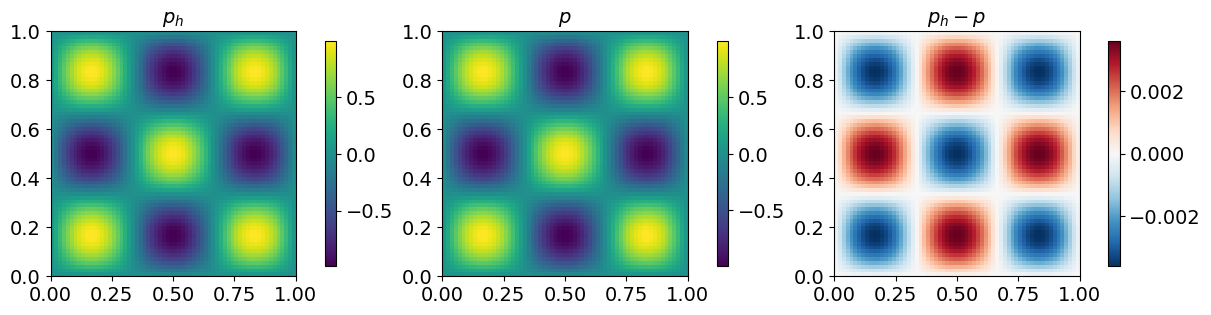

In [3]:
# Pressure and exact-field plots.
def cell_field_to_grid(field):
    return np.asarray(field, dtype=float).reshape(NY, NX)

def node_field_to_grid(field):
    return np.asarray(field, dtype=float).reshape(NY + 1, NX + 1)

p_cell = np.mean(p_local, axis=1)
p_exact_cell = p_exact(cell_centers)
with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)
    panels = [
        (cell_field_to_grid(p_cell), r"$p_h$"),
        (cell_field_to_grid(p_exact_cell), r"$p$"),
        (cell_field_to_grid(p_cell - p_exact_cell), r"$p_h-p$"),
    ]
    for ax, (grid, title) in zip(axes, panels):
        vmax = max(abs(float(np.nanmin(grid))), abs(float(np.nanmax(grid)))) if "-" in title else None
        im = ax.pcolormesh(x_edges, y_edges, grid, shading="flat", cmap="RdBu_r" if vmax else "viridis", vmin=-vmax if vmax else None, vmax=vmax if vmax else None)
        ax.set_aspect("equal")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_title(title)
        ax.grid(False)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    plt.show()


In [4]:
# Build the 65 x 65 nodal-dual mesh and integrated face fluxes.

def locate_cells(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    ix = np.floor(np.clip((pts[:, 0] - xmin) / hx, 0.0, np.nextafter(float(NX), 0.0))).astype(np.int64)
    iy = np.floor(np.clip((pts[:, 1] - ymin) / hy, 0.0, np.nextafter(float(NY), 0.0))).astype(np.int64)
    return np.clip(iy, 0, NY - 1) * NX + np.clip(ix, 0, NX - 1)


def q_cg_on_cell_numpy(points, cell_ids):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cell_ids = np.asarray(cell_ids, dtype=np.int64).reshape(-1)
    if len(pts) == 0:
        return np.zeros((0, 2), dtype=float)
    b = cell_bounds[cell_ids]
    x0 = b[:, 0]
    x1 = b[:, 1]
    y0 = b[:, 2]
    y1 = b[:, 3]
    hx_loc = x1 - x0
    hy_loc = y1 - y0
    xi = (pts[:, 0] - x0) / hx_loc
    eta = (pts[:, 1] - y0) / hy_loc
    pl = p_local[cell_ids]
    dNdx = np.column_stack((-(1.0 - eta) / hx_loc, (1.0 - eta) / hx_loc, -eta / hx_loc, eta / hx_loc))
    dNdy = np.column_stack((-(1.0 - xi) / hy_loc, -xi / hy_loc, (1.0 - xi) / hy_loc, xi / hy_loc))
    gradx = np.einsum("ij,ij->i", pl, dNdx)
    grady = np.einsum("ij,ij->i", pl, dNdy)
    return -np.column_stack((gradx, grady))


def q_cg_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    return q_cg_on_cell_numpy(pts, locate_cells(pts))


def q_cg_interface_average_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    out = np.zeros((len(pts), 2), dtype=float)
    counts = np.zeros(len(pts), dtype=float)
    tol = 1.0e-10 * h_est
    relx = (pts[:, 0] - xmin) / hx
    rely = (pts[:, 1] - ymin) / hy
    base_ix = np.floor(np.clip(relx, 0.0, np.nextafter(float(NX), 0.0))).astype(np.int64)
    base_iy = np.floor(np.clip(rely, 0.0, np.nextafter(float(NY), 0.0))).astype(np.int64)
    gx = np.rint(relx).astype(np.int64)
    gy = np.rint(rely).astype(np.int64)
    on_v = (gx > 0) & (gx < NX) & (np.abs(relx - gx) <= tol / hx)
    on_h = (gy > 0) & (gy < NY) & (np.abs(rely - gy) <= tol / hy)

    def add(mask, ix, iy):
        ids = np.flatnonzero(mask)
        if ids.size == 0:
            return
        cids = np.clip(iy[ids], 0, NY - 1) * NX + np.clip(ix[ids], 0, NX - 1)
        out[ids] += q_cg_on_cell_numpy(pts[ids], cids)
        counts[ids] += 1.0

    add(~(on_v | on_h), base_ix, base_iy)
    add(on_v & ~on_h, gx - 1, base_iy)
    add(on_v & ~on_h, gx, base_iy)
    add(on_h & ~on_v, base_ix, gy - 1)
    add(on_h & ~on_v, base_ix, gy)
    both = on_v & on_h
    add(both, gx - 1, gy - 1)
    add(both, gx, gy - 1)
    add(both, gx - 1, gy)
    add(both, gx, gy)
    return out / np.maximum(counts[:, None], 1.0)


def segment_grid_breakpoints(a, b, tol=1.0e-12):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    d = b - a
    ts = [0.0, 1.0]
    if abs(d[0]) > tol:
        lo, hi = sorted([a[0], b[0]])
        for xline in x_edges[1:-1]:
            if lo + tol < xline < hi - tol:
                ts.append(float((xline - a[0]) / d[0]))
    if abs(d[1]) > tol:
        lo, hi = sorted([a[1], b[1]])
        for yline in y_edges[1:-1]:
            if lo + tol < yline < hi - tol:
                ts.append(float((yline - a[1]) / d[1]))
    ts = np.asarray(sorted(ts), dtype=float)
    keep = [ts[0]]
    for t in ts[1:]:
        if t - keep[-1] > 1.0e-12:
            keep.append(float(t))
    return np.asarray(keep, dtype=float)


def integrate_segment_velocity(velocity_fn, a, b, normal, nq=8, split_grid=False):
    q, w = legendre_01(nq)
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    normal = np.asarray(normal, dtype=float)
    total = 0.0
    edge = b - a
    breaks = segment_grid_breakpoints(a, b) if split_grid else np.array([0.0, 1.0])
    for t0, t1 in zip(breaks[:-1], breaks[1:]):
        if t1 - t0 <= 1.0e-14:
            continue
        aa = a + t0 * edge
        bb = a + t1 * edge
        seg = bb - aa
        seg_len = float(np.linalg.norm(seg))
        pts = aa[None, :] + q[:, None] * seg[None, :]
        vel = velocity_fn(pts)
        total += seg_len * float(np.sum(w * np.einsum("ij,j->i", vel, normal)))
    return float(total)


def integrate_segment_qp(a, b, normal, nq=HARD_PINN_QP_QUAD_ORDER):
    return integrate_segment_velocity(q_p_numpy, a, b, normal, nq=nq, split_grid=False)


def integrate_segment_cg(a, b, normal, nq=8):
    return integrate_segment_velocity(q_cg_numpy, a, b, normal, nq=nq, split_grid=True)


def dual_span(i, h):
    return max(0.0, (int(i) - 0.5) * h), min(1.0, (int(i) + 0.5) * h)

x_dual_edges = np.concatenate([[xmin], (np.arange(NX) + 0.5) * hx, [xmax]])
y_dual_edges = np.concatenate([[ymin], (np.arange(NY) + 0.5) * hy, [ymax]])
dual_shape = (NY + 1, NX + 1)
dual_owner, dual_neigh, dual_face_p1, dual_face_p2, dual_face_normal = [], [], [], [], []

def add_dual_face(owner, neigh, p1, p2, normal):
    dual_owner.append(int(owner))
    dual_neigh.append(int(neigh))
    dual_face_p1.append(np.asarray(p1, dtype=float))
    dual_face_p2.append(np.asarray(p2, dtype=float))
    dual_face_normal.append(np.asarray(normal, dtype=float))

for K in range(NY + 1):
    ylo, yhi = dual_span(K, hy)
    for J in range(NX):
        x = (J + 0.5) * hx
        add_dual_face(node_id(J, K), node_id(J + 1, K), [x, ylo], [x, yhi], [1.0, 0.0])
for J in range(NX + 1):
    xlo, xhi = dual_span(J, hx)
    for K in range(NY):
        y = (K + 0.5) * hy
        add_dual_face(node_id(J, K), node_id(J, K + 1), [xlo, y], [xhi, y], [0.0, 1.0])
for K in range(NY + 1):
    ylo, yhi = dual_span(K, hy)
    add_dual_face(node_id(0, K), -1, [xmin, ylo], [xmin, yhi], [-1.0, 0.0])
    add_dual_face(node_id(NX, K), -1, [xmax, ylo], [xmax, yhi], [1.0, 0.0])
for J in range(NX + 1):
    xlo, xhi = dual_span(J, hx)
    add_dual_face(node_id(J, 0), -1, [xlo, ymin], [xhi, ymin], [0.0, -1.0])
    add_dual_face(node_id(J, NY), -1, [xlo, ymax], [xhi, ymax], [0.0, 1.0])

dual_owner = np.asarray(dual_owner, dtype=np.int64)
dual_neigh = np.asarray(dual_neigh, dtype=np.int64)
dual_face_p1 = np.asarray(dual_face_p1, dtype=float)
dual_face_p2 = np.asarray(dual_face_p2, dtype=float)
dual_face_normal = np.asarray(dual_face_normal, dtype=float)
dual_has_neighbor = dual_neigh >= 0
dual_is_boundary = ~dual_has_neighbor
assert len(dual_owner) == NX * (NY + 1) + NY * (NX + 1) + 2 * (NX + 1) + 2 * (NY + 1)

dual_pv = np.zeros(n_nodes, dtype=float)
dual_source_rate = np.zeros(n_nodes, dtype=float)
for K in range(NY + 1):
    ylo, yhi = dual_span(K, hy)
    for J in range(NX + 1):
        xlo, xhi = dual_span(J, hx)
        area = (xhi - xlo) * (yhi - ylo)
        vid = node_id(J, K)
        dual_pv[vid] = PHI_MATRIX * area
        dual_source_rate[vid] = source_integral_rect(xlo, xhi, ylo, yhi)

source_rate_cell = np.array([source_integral_rect(x0, x1, y0, y1) for x0, x1, y0, y1 in cell_bounds], dtype=float)
source_density_cell = source_rate_cell / cell_area
source_rate_positive = float(np.sum(np.maximum(dual_source_rate, 0.0)))
source_rate_negative = float(np.sum(np.minimum(dual_source_rate, 0.0)))

dual_flux_by_method = {
    "CG": np.array([integrate_segment_cg(a, b, n, nq=8) for a, b, n in zip(dual_face_p1, dual_face_p2, dual_face_normal)], dtype=float),
    "Exact": np.array([exact_axis_segment_flux(a, b, n) for a, b, n in zip(dual_face_p1, dual_face_p2, dual_face_normal)], dtype=float),
}
qp_dual_flux = np.array([integrate_segment_qp(a, b, n) for a, b, n in zip(dual_face_p1, dual_face_p2, dual_face_normal)], dtype=float)


def dual_single_phase_residual(Fout):
    res = np.zeros(n_nodes, dtype=float)
    np.add.at(res, dual_owner, Fout)
    np.add.at(res, dual_neigh[dual_has_neighbor], -Fout[dual_has_neighbor])
    return res - dual_source_rate

R_xi_exact_gate = dual_single_phase_residual(dual_flux_by_method["Exact"])
R_xi_cg_gate = dual_single_phase_residual(dual_flux_by_method["CG"])
R_xi_qp_gate = dual_single_phase_residual(qp_dual_flux)
print(f"Dual mesh: CVs={n_nodes}, faces={len(dual_owner)}, source+={source_rate_positive:.6e}, source-={source_rate_negative:.6e}")
print("Sanity gate (b), exact flux on xi dual CVs:", residual_stats(R_xi_exact_gate))
print("Particular flux q_p on xi dual CVs:", residual_stats(R_xi_qp_gate))
print("CG flux on xi dual CVs:", residual_stats(R_xi_cg_gate))



Dual mesh: CVs=4225, faces=8580, source+=3.998554e+01, source-=-3.198554e+01
Sanity gate (b), exact flux on xi dual CVs: n=4225 mean|R|=7.406990e-18 median|R|=6.938894e-18 rmse=9.895422e-18 max|R|=4.943962e-17 sum(R)=+4.043989e-16
Particular flux q_p on xi dual CVs: n=4225 mean|R|=5.060811e-17 median|R|=3.209238e-17 rmse=7.377479e-17 max|R|=3.885781e-16 sum(R)=+1.441493e-15
CG flux on xi dual CVs: n=4225 mean|R|=3.076541e-05 median|R|=1.598260e-05 rmse=7.215654e-05 max|R|=3.995535e-04 sum(R)=-2.890440e-02


In [5]:
# Hard-conservative stream-function PINN trained on CG dual-face fluxes.
# q_theta = q_p + curl(psi_theta), curl(psi)=(psi_y, -psi_x).

hard_pinn_loss_history = []
hard_pinn_unweighted_rmse_history = []
HARD_CURL_PINN_ACTIVE = False
PINN_ACTIVE = False

_logk_node = np.zeros((NY + 1, NX + 1), dtype=float)
_logk_mean = 0.0
_logk_std = 1.0


def hard_pinn_logk_feature_np(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    return np.zeros((len(pts), 1), dtype=np.float32)


def hard_pinn_features_np(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    x = pts[:, 0:1]
    y = pts[:, 1:2]
    feats = [x, y]
    for freq in HARD_PINN_FOURIER_FREQS:
        argx = 2.0 * np.pi * freq * x
        argy = 2.0 * np.pi * freq * y
        feats.extend([np.sin(argx), np.cos(argx), np.sin(argy), np.cos(argy)])
    if HARD_PINN_USE_LOGK:
        feats.append(hard_pinn_logk_feature_np(pts))
    return np.hstack(feats).astype(np.float32)


def hard_pinn_logk_feature_torch(x_t):
    return torch.zeros((x_t.shape[0], 1), dtype=x_t.dtype, device=x_t.device)


def hard_pinn_features_torch(x_t):
    feats = [x_t[:, 0:1], x_t[:, 1:2]]
    for freq in HARD_PINN_FOURIER_FREQS:
        omega = x_t.new_tensor(2.0 * np.pi * float(freq))
        feats.extend([torch.sin(omega * x_t[:, 0:1]), torch.cos(omega * x_t[:, 0:1]), torch.sin(omega * x_t[:, 1:2]), torch.cos(omega * x_t[:, 1:2])])
    if HARD_PINN_USE_LOGK:
        feats.append(hard_pinn_logk_feature_torch(x_t))
    return torch.cat(feats, dim=1)


def curl_segment_sign(p1, p2, normals):
    edge = np.asarray(p2, dtype=float) - np.asarray(p1, dtype=float)
    length = np.linalg.norm(edge, axis=1)
    right_normal = np.column_stack([edge[:, 1], -edge[:, 0]]) / np.maximum(length[:, None], 1.0e-300)
    sign = np.einsum("ij,ij->i", np.asarray(normals, dtype=float), right_normal)
    return np.where(sign >= 0.0, 1.0, -1.0).astype(np.float64)


def make_hard_pinn_weights(target_flux):
    target_flux = np.asarray(target_flux, dtype=float).reshape(-1)
    if HARD_PINN_USE_RELATIVE_WEIGHTS:
        eps = 0.05 * float(np.quantile(np.abs(target_flux), 0.95) + 1.0e-12)
        raw = 1.0 / (target_flux ** 2 + eps ** 2)
        med = float(np.median(raw))
        lo = med / float(HARD_PINN_WEIGHT_CLIP_FACTOR)
        hi = med * float(HARD_PINN_WEIGHT_CLIP_FACTOR)
        weights = np.clip(raw, lo, hi)
    else:
        eps = np.nan
        raw = np.ones_like(target_flux)
        weights = raw.copy()
        med = lo = hi = 1.0
    weights /= float(np.mean(weights))
    return weights, eps, raw, med, lo, hi


def print_hard_pinn_weight_summary(label, target_flux, weights, eps, raw, med, lo, hi):
    print(
        f"{label}: relative={HARD_PINN_USE_RELATIVE_WEIGHTS}, eps={eps:.3e}, "
        f"weight range=[{weights.min():.3e},{weights.max():.3e}]"
    )
    print(
        f"  |F| q50/q95/max={np.quantile(np.abs(target_flux), 0.50):.3e}/"
        f"{np.quantile(np.abs(target_flux), 0.95):.3e}/{np.max(np.abs(target_flux)):.3e}"
    )


def finish_hardcurl_diagnostics(pred_flux, target_flux, mode_label, loss_history=None, psi_model=None):
    global hard_pinn_dual_flux, hard_pinn_dual_flux_error, hard_pinn_loss_history
    global hard_pinn_flux_l2, hard_pinn_flux_rmse, hard_pinn_flux_rel_l2
    global PINN_ACTIVE, HARD_CURL_PINN_ACTIVE, q_rec_numpy
    hard_pinn_dual_flux = np.asarray(pred_flux, dtype=float).reshape(-1)
    target_flux = np.asarray(target_flux, dtype=float).reshape(-1)
    hard_pinn_dual_flux_error = hard_pinn_dual_flux - target_flux
    hard_pinn_flux_l2 = float(np.sqrt(np.sum(hard_pinn_dual_flux_error ** 2)))
    hard_pinn_flux_rmse = float(np.sqrt(np.mean(hard_pinn_dual_flux_error ** 2)))
    hard_pinn_flux_rel_l2 = hard_pinn_flux_l2 / max(float(np.sqrt(np.sum(target_flux ** 2))), 1.0e-300)
    dual_flux_by_method["PINN"] = hard_pinn_dual_flux
    PINN_ACTIVE = True
    HARD_CURL_PINN_ACTIVE = True
    if loss_history is not None:
        hard_pinn_loss_history = list(loss_history)
    if psi_model is not None and TORCH_AVAILABLE:
        def q_hardcurl_pinn_numpy(points, batch=100000):
            pts = np.asarray(points, dtype=float).reshape(-1, 2)
            out = np.zeros_like(pts)
            psi_model.eval()
            model_dtype = next(psi_model.parameters()).dtype
            for start in range(0, len(pts), batch):
                pp = pts[start:start + batch]
                x_t = torch.as_tensor(pp, dtype=model_dtype, device=device).clone().detach().requires_grad_(True)
                psi = psi_model(hard_pinn_features_torch(x_t))
                grad = torch.autograd.grad(psi.sum(), x_t, create_graph=False)[0]
                curl = torch.stack([grad[:, 1], -grad[:, 0]], dim=1).detach().cpu().numpy()
                out[start:start + batch] = q_p_numpy(pp) + curl
            return out
        q_rec_numpy = q_hardcurl_pinn_numpy
    print(f"Hard-conservative stream reconstruction ({mode_label}):")
    if hard_pinn_loss_history:
        print(f"  final training loss={hard_pinn_loss_history[-1]:.6e}; best={np.min(hard_pinn_loss_history):.6e}")
    print(f"  face-flux error vs CG: L2={hard_pinn_flux_l2:.6e}, relL2={hard_pinn_flux_rel_l2:.3e}, RMSE={hard_pinn_flux_rmse:.6e}, max={np.max(np.abs(hard_pinn_dual_flux_error)):.6e}")


if not ENABLE_HARD_CURL_PINN:
    print("Hard-curl PINN disabled.")
elif not TORCH_AVAILABLE:
    print("Torch unavailable; hard-curl PINN training skipped.")
else:
    class HardCurlPsiNet(nn.Module):
        def __init__(self, in_dim, hidden_dim=HARD_PINN_HIDDEN_DIM, depth=HARD_PINN_DEPTH):
            super().__init__()
            layers = [nn.Linear(in_dim, hidden_dim), nn.SiLU()]
            for _ in range(depth - 1):
                layers.extend([nn.Linear(hidden_dim, hidden_dim), nn.SiLU()])
            layers.append(nn.Linear(hidden_dim, 1))
            self.net = nn.Sequential(*layers)
        def forward(self, features):
            return self.net(features).squeeze(-1)

    p1_np = np.asarray(dual_face_p1, dtype=float)
    p2_np = np.asarray(dual_face_p2, dtype=float)
    sign_np = curl_segment_sign(p1_np, p2_np, dual_face_normal)
    qp_flux_np = qp_dual_flux.copy()
    target_flux_np = dual_flux_by_method["CG"].copy()
    feat_a_np = hard_pinn_features_np(p1_np)
    feat_b_np = hard_pinn_features_np(p2_np)
    weights_np, eps, raw_weights_np, w_med, w_lo, w_hi = make_hard_pinn_weights(target_flux_np)
    print_hard_pinn_weight_summary("Hard-curl loss weighting", target_flux_np, weights_np, eps, raw_weights_np, w_med, w_lo, w_hi)

    p1_t = torch.as_tensor(p1_np, dtype=HARD_PINN_TORCH_DTYPE, device=device)
    p2_t = torch.as_tensor(p2_np, dtype=HARD_PINN_TORCH_DTYPE, device=device)
    feat_a = hard_pinn_features_torch(p1_t)
    feat_b = hard_pinn_features_torch(p2_t)
    sign_t = torch.as_tensor(sign_np, dtype=HARD_PINN_TORCH_DTYPE, device=device)
    qp_flux_t = torch.as_tensor(qp_flux_np, dtype=HARD_PINN_TORCH_DTYPE, device=device)
    target_flux_t = torch.as_tensor(target_flux_np, dtype=HARD_PINN_TORCH_DTYPE, device=device)
    weights_t = torch.as_tensor(weights_np, dtype=HARD_PINN_TORCH_DTYPE, device=device)

    psi_net = HardCurlPsiNet(int(feat_a.shape[1])).to(device=device, dtype=HARD_PINN_TORCH_DTYPE)
    hard_pinn_param_count = sum(p.numel() for p in psi_net.parameters() if p.requires_grad)
    hard_pinn_architecture = [int(feat_a.shape[1])] + [HARD_PINN_HIDDEN_DIM] * HARD_PINN_DEPTH + [1]
    print("Hard-curl stream-function PINN complexity:")
    print(f"  architecture: {' -> '.join(str(v) for v in hard_pinn_architecture)}")
    print(f"  hidden layers={HARD_PINN_DEPTH}, width={HARD_PINN_HIDDEN_DIM}, activation=SiLU, trainable parameters={hard_pinn_param_count}")
    print(f"  features: x,y + {len(HARD_PINN_FOURIER_FREQS)} Fourier frequencies + constant log10(kappa)={HARD_PINN_USE_LOGK}")

    hard_pinn_loaded = False
    if HARD_PINN_LOAD_CHECKPOINT and CHECKPOINT_PATH.exists():
        try:
            try:
                ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
            except TypeError:
                ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu")
            arch = ckpt.get("architecture", {})
            arch_ok = (
                int(arch.get("input_dim", -1)) == int(feat_a.shape[1])
                and int(arch.get("hidden_dim", -1)) == int(HARD_PINN_HIDDEN_DIM)
                and int(arch.get("depth", -1)) == int(HARD_PINN_DEPTH)
                and int(ckpt.get("mms_k", -999)) == int(MMS_K)
            )
            if arch_ok:
                psi_net.load_state_dict({k: v.to(device=device, dtype=HARD_PINN_TORCH_DTYPE) for k, v in ckpt["state_dict"].items()})
                hard_pinn_loss_history = list(np.asarray(ckpt.get("training", {}).get("loss_history", []), dtype=float))
                hard_pinn_unweighted_rmse_history = list(np.asarray(ckpt.get("training", {}).get("unweighted_rmse_history", []), dtype=float))
                hard_pinn_loaded = True
                print(f"Loaded hard-curl PINN checkpoint: {CHECKPOINT_PATH.name}")
            else:
                print("Existing checkpoint architecture/k mismatch; retraining.")
        except Exception as exc:
            print(f"Checkpoint load failed ({exc}); retraining.")

    def prediction_torch():
        psi_a = psi_net(feat_a)
        psi_b = psi_net(feat_b)
        return qp_flux_t + sign_t * (psi_b - psi_a)

    def loss_torch():
        pred = prediction_torch()
        err = pred - target_flux_t
        weighted_loss = torch.mean(weights_t * err ** 2)
        unweighted_mse = torch.mean(err ** 2)
        return weighted_loss, pred, err, unweighted_mse

    if not hard_pinn_loaded:
        opt = torch.optim.Adam(psi_net.parameters(), lr=HARD_PINN_LR)
        scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[int(0.55 * HARD_PINN_EPOCHS), int(0.82 * HARD_PINN_EPOCHS)], gamma=0.35)
        t0 = time.perf_counter()
        best_score = np.inf
        best_loss = np.inf
        best_state = None
        for epoch in tqdm(range(1, HARD_PINN_EPOCHS + 1), desc="Hard-curl MMS stream PINN"):
            opt.zero_grad(set_to_none=True)
            loss, pred, err, unweighted_mse = loss_torch()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(psi_net.parameters(), max_norm=10.0)
            opt.step()
            scheduler.step()
            loss_val = float(loss.detach().cpu())
            mse_val = float(unweighted_mse.detach().cpu())
            rmse_val = float(np.sqrt(mse_val))
            hard_pinn_loss_history.append(loss_val)
            hard_pinn_unweighted_rmse_history.append(rmse_val)
            if mse_val < best_score:
                best_score = mse_val
                best_loss = loss_val
                best_state = {k: v.detach().cpu().clone() for k, v in psi_net.state_dict().items()}
            if epoch == 1 or epoch == HARD_PINN_EPOCHS or epoch % HARD_PINN_PRINT_EVERY == 0:
                print(f"  epoch {epoch:5d}: train-loss={loss_val:.6e}, face-rmse={rmse_val:.6e}")
        if best_state is not None:
            psi_net.load_state_dict(best_state)

        if HARD_PINN_LBFGS_POLISH:
            print(f"  starting L-BFGS polish: max_iter={HARD_PINN_LBFGS_MAX_ITER}, history={HARD_PINN_LBFGS_HISTORY_SIZE}, dtype=float64")
            psi_net = psi_net.to(dtype=torch.float64)
            feat_a = feat_a.to(dtype=torch.float64)
            feat_b = feat_b.to(dtype=torch.float64)
            sign_t = sign_t.to(dtype=torch.float64)
            qp_flux_t = qp_flux_t.to(dtype=torch.float64)
            target_flux_t = target_flux_t.to(dtype=torch.float64)
            weights_t = weights_t.to(dtype=torch.float64)
            lbfgs = torch.optim.LBFGS(
                psi_net.parameters(), max_iter=HARD_PINN_LBFGS_MAX_ITER,
                history_size=HARD_PINN_LBFGS_HISTORY_SIZE,
                tolerance_grad=HARD_PINN_LBFGS_TOL_GRAD,
                tolerance_change=HARD_PINN_LBFGS_TOL_CHANGE,
                line_search_fn="strong_wolfe",
            )
            calls = [0]
            best_score_box = [best_score]
            best_state_box = [best_state]
            best_loss_box = [best_loss]
            last_improve_call = [0]
            loss_before, _, _, mse_before = loss_torch()
            print(f"  L-BFGS call {0:5d}: train-loss={float(loss_before.detach().cpu()):.6e}, face-rmse={float(torch.sqrt(mse_before).detach().cpu()):.6e}", flush=True)

            class _HardPinnLBFGSEarlyStop(Exception):
                pass

            def closure():
                lbfgs.zero_grad(set_to_none=True)
                loss, _, _, mse = loss_torch()
                loss.backward()
                loss_val = float(loss.detach().cpu())
                mse_val = float(mse.detach().cpu())
                hard_pinn_loss_history.append(loss_val)
                hard_pinn_unweighted_rmse_history.append(float(np.sqrt(mse_val)))
                calls[0] += 1
                if mse_val + HARD_PINN_LBFGS_MIN_DELTA < best_score_box[0]:
                    best_score_box[0] = mse_val
                    best_loss_box[0] = loss_val
                    best_state_box[0] = {k: v.detach().cpu().clone() for k, v in psi_net.state_dict().items()}
                    last_improve_call[0] = calls[0]
                if calls[0] == 1 or calls[0] % HARD_PINN_LBFGS_PRINT_EVERY == 0:
                    print(f"  L-BFGS call {calls[0]:5d}: train-loss={loss_val:.6e}, face-rmse={np.sqrt(mse_val):.6e}, best-rmse={np.sqrt(best_score_box[0]):.6e}", flush=True)
                if (calls[0] >= HARD_PINN_LBFGS_MIN_CALLS and
                        calls[0] - last_improve_call[0] >= HARD_PINN_LBFGS_EARLY_STOP_PATIENCE):
                    raise _HardPinnLBFGSEarlyStop(
                        f"no face-RMSE improvement larger than {HARD_PINN_LBFGS_MIN_DELTA:.1e} "
                        f"for {HARD_PINN_LBFGS_EARLY_STOP_PATIENCE} calls"
                    )
                return loss
            try:
                lbfgs.step(closure)
            except _HardPinnLBFGSEarlyStop as exc:
                print(f"  L-BFGS early stop after {calls[0]} calls: {exc}", flush=True)
            if best_state_box[0] is not None:
                psi_net.load_state_dict(best_state_box[0])
            loss_after, _, _, mse_after = loss_torch()
            print(f"  L-BFGS polish calls={calls[0]}, face-rmse {float(torch.sqrt(mse_before).detach().cpu()):.6e} -> {float(torch.sqrt(mse_after).detach().cpu()):.6e}")
        hard_pinn_training_time = time.perf_counter() - t0
    else:
        hard_pinn_training_time = 0.0

    with torch.no_grad():
        pred = prediction_torch().detach().cpu().numpy().astype(float)
    print(f"  PINN training time = {hard_pinn_training_time:.3f} s")
    finish_hardcurl_diagnostics(pred, target_flux_np, "MLP PINN (loaded checkpoint)" if hard_pinn_loaded else "MLP PINN", hard_pinn_loss_history, psi_net)


Hard-curl loss weighting: relative=False, eps=nan, weight range=[1.000e+00,1.000e+00]
  |F| q50/q95/max=5.284e-02/1.369e-01/1.470e-01
Hard-curl stream-function PINN complexity:
  architecture: 27 -> 96 -> 96 -> 96 -> 96 -> 1
  hidden layers=4, width=96, activation=SiLU, trainable parameters=30721
  features: x,y + 6 Fourier frequencies + constant log10(kappa)=True


Hard-curl MMS stream PINN:   0%|          | 2/5000 [00:00<13:49,  6.03it/s]

  epoch     1: train-loss=2.678333e-02, face-rmse=1.636561e-01


Hard-curl MMS stream PINN:  10%|█         | 505/5000 [00:14<01:58, 38.09it/s]

  epoch   500: train-loss=2.032477e-05, face-rmse=4.508300e-03


...

  epoch  4000: train-loss=1.146735e-06, face-rmse=1.070857e-03


Hard-curl MMS stream PINN:  90%|█████████ | 4506/5000 [02:06<00:14, 35.19it/s]

  epoch  4500: train-loss=1.057251e-06, face-rmse=1.028227e-03


Hard-curl MMS stream PINN: 100%|██████████| 5000/5000 [02:21<00:00, 35.33it/s]


  epoch  5000: train-loss=9.837053e-07, face-rmse=9.918192e-04
  starting L-BFGS polish: max_iter=3000, history=50, dtype=float64
  L-BFGS call     0: train-loss=9.835492e-07, face-rmse=9.917405e-04
  L-BFGS call     1: train-loss=9.835492e-07, face-rmse=9.917405e-04, best-rmse=9.917405e-04
  L-BFGS call    25: train-loss=9.834553e-07, face-rmse=9.916931e-04, best-rmse=9.916931e-04
  L-BFGS call    50: train-loss=9.834386e-07, face-rmse=9.916847e-04, best-rmse=9.916824e-04
  L-BFGS call    75: train-loss=9.834110e-07, face-rmse=9.916708e-04, best-rmse=9.916708e-04
  L-BFGS call   100: train-loss=9.834482e-07, face-rmse=9.916896e-04, best-rmse=9.916602e-04
  L-BFGS call   125: train-loss=9.833672e-07, face-rmse=9.916487e-04, best-rmse=9.916487e-04
  L-BFGS call   150: train-loss=9.833509e-07, face-rmse=9.916405e-04, best-rmse=9.916382e-04
  L-BFGS call   175: train-loss=9.833237e-07, face-rmse=9.916268e-04, best-rmse=9.916268e-04
  L-BFGS call   200: train-loss=9.833605e-07, face-rmse=9

In [6]:
# Save hard-curl PINN checkpoint for reuse.
if not TORCH_AVAILABLE:
    raise RuntimeError("Torch is unavailable; no PyTorch hard-curl network to save.")
if not HARD_CURL_PINN_ACTIVE or "psi_net" not in globals():
    raise RuntimeError("Run the hard-curl PINN training cell before saving the checkpoint.")

CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
psi_net.eval()
state_dict_cpu = {k: v.detach().cpu() for k, v in psi_net.state_dict().items()}
ckpt = {
    "format": "hardcurl_stream_pinn_mms_v1",
    "description": "q_theta = q_p + curl(psi_theta), trained on Q1 Deng dual CG fluxes for MMS sin(k*pi*x)sin(k*pi*y).",
    "mms_k": int(MMS_K),
    "state_dict": state_dict_cpu,
    "state_dtype": str(next(psi_net.parameters()).dtype).replace("torch.", ""),
    "architecture": {
        "input_dim": int(hard_pinn_architecture[0]),
        "hidden_dim": int(HARD_PINN_HIDDEN_DIM),
        "depth": int(HARD_PINN_DEPTH),
        "output_dim": 1,
        "activation": "SiLU",
        "fourier_freqs": np.asarray(HARD_PINN_FOURIER_FREQS, dtype=float),
        "use_logk": bool(HARD_PINN_USE_LOGK),
    },
    "geometry": {"nx": int(NX), "ny": int(NY), "hx": float(hx), "hy": float(hy)},
    "training": {
        "epochs": int(HARD_PINN_EPOCHS),
        "lr": float(HARD_PINN_LR),
        "loss_history": np.asarray(hard_pinn_loss_history, dtype=float),
        "unweighted_rmse_history": np.asarray(hard_pinn_unweighted_rmse_history, dtype=float),
        "training_time": float(hard_pinn_training_time) if "hard_pinn_training_time" in globals() else np.nan,
    },
    "diagnostics": {
        "dual_flux": np.asarray(hard_pinn_dual_flux, dtype=float),
        "dual_flux_error_vs_cg": np.asarray(hard_pinn_dual_flux_error, dtype=float),
        "dual_flux_l2_vs_cg": float(hard_pinn_flux_l2),
    },
}
torch.save(ckpt, CHECKPOINT_PATH)
print(f"Saved hard-curl MMS checkpoint to: {CHECKPOINT_PATH}")
print(f"  dtype={ckpt['state_dtype']}, parameters={sum(v.numel() for v in state_dict_cpu.values())}, file={CHECKPOINT_PATH.name}")


Saved hard-curl MMS checkpoint to: case3_ecmor/hardcurl_pinn_mms_k3_Q1_64x64.pt
  dtype=float64, parameters=30721, file=hardcurl_pinn_mms_k3_Q1_64x64.pt


Pressure L2 errors:
  CG vs exact   : 1.069102e-03
  PINN vs exact : N/A (the hard-curl network reconstructs flux only)
  PINN vs CG    : N/A (the hard-curl network reconstructs flux only)
Dual-face integrated flux L2 errors:
  CG vs exact    L2=8.496802e-03, RMSE=9.173010e-05, max=5.310453e-04
  PINN vs exact  L2=9.133252e-02, RMSE=9.860111e-04, max=4.333505e-03
  PINN vs CG     L2=9.171456e-02, RMSE=9.901356e-04, max=4.512408e-03


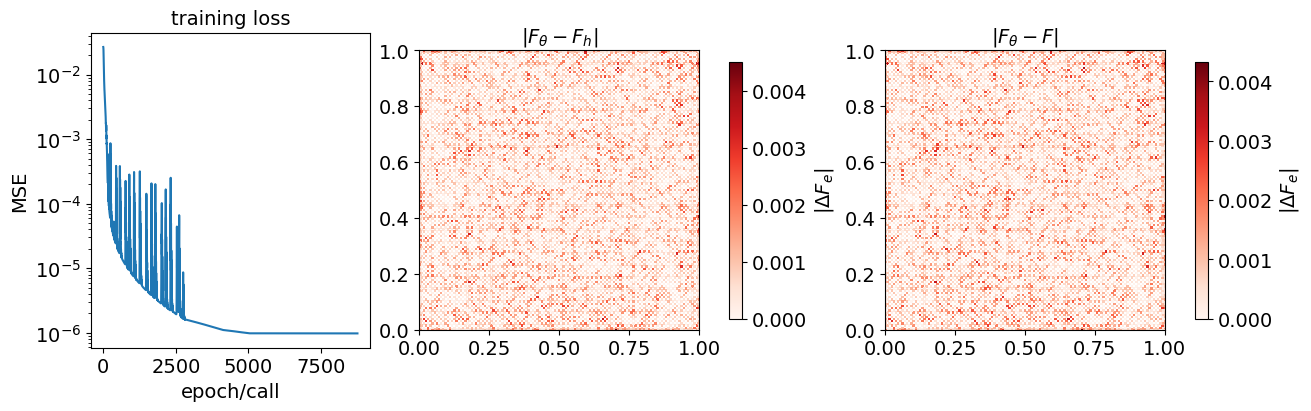

In [7]:
# Training loss and flux-error diagnostics.
if not HARD_CURL_PINN_ACTIVE:
    raise RuntimeError("Run the hard-curl PINN training cell first.")

exact_dual_flux = dual_flux_by_method["Exact"]
cg_dual_flux = dual_flux_by_method["CG"]
pinn_dual_flux = dual_flux_by_method["PINN"]
flux_error_rows = [
    ("CG vs exact", cg_dual_flux - exact_dual_flux),
    ("PINN vs exact", pinn_dual_flux - exact_dual_flux),
    ("PINN vs CG", pinn_dual_flux - cg_dual_flux),
]
print("Pressure L2 errors:")
print(f"  CG vs exact   : {p_l2:.6e}")
print("  PINN vs exact : N/A (the hard-curl network reconstructs flux only)")
print("  PINN vs CG    : N/A (the hard-curl network reconstructs flux only)")
print("Dual-face integrated flux L2 errors:")
for name, err in flux_error_rows:
    print(f"  {name:<14} L2={np.sqrt(np.sum(err ** 2)):.6e}, RMSE={np.sqrt(np.mean(err ** 2)):.6e}, max={np.max(np.abs(err)):.6e}")

with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    ncols = 3
    fig, axes = plt.subplots(1, ncols, figsize=(13.0, 4.0), constrained_layout=True)
    if hard_pinn_loss_history:
        axes[0].semilogy(np.arange(1, len(hard_pinn_loss_history) + 1), hard_pinn_loss_history, lw=1.5)
        axes[0].set_xlabel("epoch/call")
        axes[0].set_ylabel("MSE")
    axes[0].set_title("training loss")
    axes[0].grid(False)

    cent = 0.5 * (dual_face_p1 + dual_face_p2)
    for ax, (title, err) in zip(axes[1:], [(r"$|F_\theta-F_h|$", pinn_dual_flux - cg_dual_flux), (r"$|F_\theta-F|$", pinn_dual_flux - exact_dual_flux)]):
        vals = np.abs(err)
        vmax = max(float(np.max(vals)), 1.0e-14)
        sc = ax.scatter(cent[:, 0], cent[:, 1], c=vals, s=3.0, marker="s", cmap="Reds", vmin=0.0, vmax=vmax, linewidths=0.0, rasterized=True)
        ax.set_aspect("equal")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_title(title)
        ax.grid(False)
        cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.03)
        cbar.set_label(r"$|\Delta F_e|$")
    plt.show()



R_tau batched quadrature: points=1572864, elapsed=31.46 s
Element residual R_tau = sum_e int_e v.n ds - int_K f
  Exact: n=4096 mean|R|=6.238157e-17 median|R|=4.857226e-17 rmse=8.195816e-17 max|R|=3.677614e-16 sum(R)=+1.418052e-15
  CG   : n=4096 mean|R|=6.340868e-05 median|R|=5.587258e-05 rmse=7.821162e-05 max|R|=1.563290e-04 sum(R)=-2.890440e-02
  PINN : n=4096 mean|R|=1.066094e-16 median|R|=8.326673e-17 rmse=1.391803e-16 max|R|=5.898060e-16 sum(R)=-6.896657e-15
Nodal-dual residual R_xi = sum_e int_e v.n ds - int_C f
  Exact: n=4225 mean|R|=7.406990e-18 median|R|=6.938894e-18 rmse=9.895422e-18 max|R|=4.943962e-17 sum(R)=+4.043989e-16
  CG   : n=4225 mean|R|=3.076541e-05 median|R|=1.598260e-05 rmse=7.215654e-05 max|R|=3.995535e-04 sum(R)=-2.890440e-02
  PINN : n=4225 mean|R|=5.340307e-09 median|R|=2.214603e-09 rmse=9.304563e-09 max|R|=5.216545e-08 sum(R)=-2.272427e-07


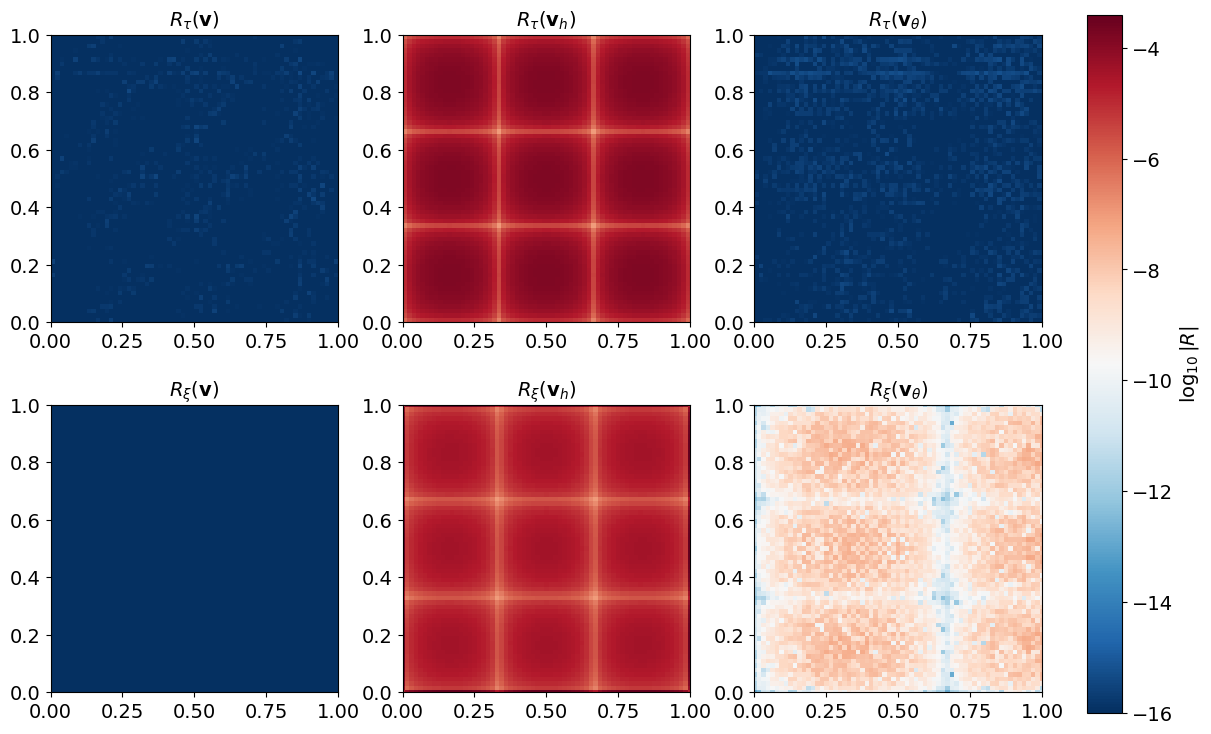

/tmp/ipykernel_522153/98806586.py:190: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  det = abs(np.cross(a - c, b - c))


R_zeta batched quadrature: CVs=4278, points=964128, elapsed=19.19 s
Rotated control-volume residual R_zeta
  zeta CVs=4278, edge quadrature=24, source quadrature=24
  Exact: n=4278 mean|R|=4.627659e-17 median|R|=3.469447e-17 rmse=6.291966e-17 max|R|=3.920475e-16 sum(R)=+3.407677e-15
  CG   : n=4278 mean|R|=1.958020e-03 median|R|=1.165591e-03 rmse=2.920443e-03 max|R|=1.599399e-02 sum(R)=-2.890440e-02
  PINN : n=4278 mean|R|=1.541581e-16 median|R|=1.110223e-16 rmse=2.188598e-16 max|R|=1.468010e-15 sum(R)=+9.774229e-15


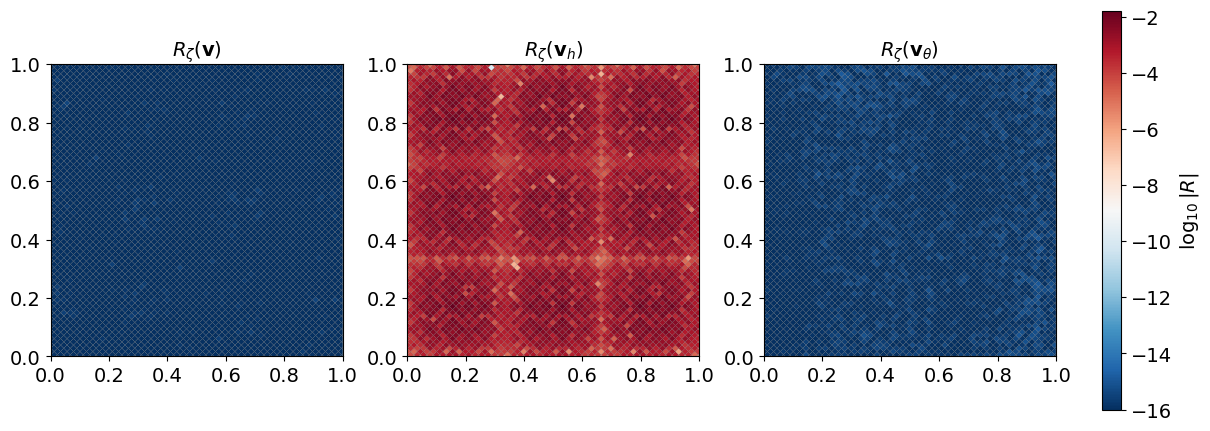

In [11]:
# Conservation residual diagnostics on tau, xi, and rotated zeta control volumes.
if not HARD_CURL_PINN_ACTIVE:
    raise RuntimeError("Run the hard-curl PINN training cell before conservation diagnostics.")


def log_abs(vals):
    return np.log10(np.maximum(np.abs(np.asarray(vals, dtype=float)), CONSERVATION_EPS))


def _residual_from_quadrature(points, normal_weights, owners, source, velocity_fn=None, cell_ids=None):
    if cell_ids is None:
        vel = velocity_fn(points)
    else:
        vel = q_cg_on_cell_numpy(points, cell_ids)
    contrib = np.einsum("ij,ij->i", vel, normal_weights)
    flux = np.zeros_like(source, dtype=float)
    np.add.at(flux, owners, contrib)
    return flux - source


# R_tau: batch all edge quadrature points.  This avoids thousands of tiny torch/autograd calls.
def build_tau_quadrature(nq=CONSERVATION_RTAU_EDGE_NQ):
    q, w = legendre_01(nq)
    pts_list, nw_list, owner_list = [], [], []
    for cid, (x0, x1, y0, y1) in enumerate(cell_bounds):
        edges = [
            (np.array([x0, y0]), np.array([x1, y0]), np.array([0.0, -1.0])),
            (np.array([x1, y0]), np.array([x1, y1]), np.array([1.0, 0.0])),
            (np.array([x1, y1]), np.array([x0, y1]), np.array([0.0, 1.0])),
            (np.array([x0, y1]), np.array([x0, y0]), np.array([-1.0, 0.0])),
        ]
        for a, b, normal in edges:
            seg = b - a
            seg_len = float(np.linalg.norm(seg))
            pts = a[None, :] + q[:, None] * seg[None, :]
            pts_list.append(pts)
            nw_list.append(w[:, None] * (seg_len * normal[None, :]))
            owner_list.append(np.full(nq, cid, dtype=np.int64))
    return {
        "points": np.vstack(pts_list),
        "normal_weights": np.vstack(nw_list),
        "owners": np.concatenate(owner_list),
    }


def integrate_cell_boundary_exact_axis(cid):
    x0, x1, y0, y1 = cell_bounds[int(cid)]
    return (
        exact_axis_segment_flux([x0, y0], [x1, y0], [0.0, -1.0])
        + exact_axis_segment_flux([x1, y0], [x1, y1], [1.0, 0.0])
        + exact_axis_segment_flux([x1, y1], [x0, y1], [0.0, 1.0])
        + exact_axis_segment_flux([x0, y1], [x0, y0], [-1.0, 0.0])
    )


t0_res = time.perf_counter()
tau_q = build_tau_quadrature(CONSERVATION_RTAU_EDGE_NQ)
R_tau_exact = _residual_from_quadrature(tau_q["points"], tau_q["normal_weights"], tau_q["owners"], source_rate_cell, velocity_fn=q_exact)
R_tau_cg = _residual_from_quadrature(tau_q["points"], tau_q["normal_weights"], tau_q["owners"], source_rate_cell, velocity_fn=q_cg_interface_average_numpy)
R_tau_pinn = _residual_from_quadrature(tau_q["points"], tau_q["normal_weights"], tau_q["owners"], source_rate_cell, velocity_fn=q_rec_numpy)
print(f"R_tau batched quadrature: points={len(tau_q['points'])}, elapsed={time.perf_counter() - t0_res:.2f} s")

R_xi_exact = dual_single_phase_residual(dual_flux_by_method["Exact"])
R_xi_cg = dual_single_phase_residual(dual_flux_by_method["CG"])
R_xi_pinn = dual_single_phase_residual(dual_flux_by_method["PINN"])

print("Element residual R_tau = sum_e int_e v.n ds - int_K f")
print("  Exact:", residual_stats(R_tau_exact))
print("  CG   :", residual_stats(R_tau_cg))
print("  PINN :", residual_stats(R_tau_pinn))
print("Nodal-dual residual R_xi = sum_e int_e v.n ds - int_C f")
print("  Exact:", residual_stats(R_xi_exact))
print("  CG   :", residual_stats(R_xi_cg))
print("  PINN :", residual_stats(R_xi_pinn))

with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(2, 3, figsize=(12, 7.4), constrained_layout=True)
    tau_panels = [(R_tau_exact, r"$R_\tau(\mathbf{v})$"), (R_tau_cg, r"$R_\tau(\mathbf{v}_h)$"), (R_tau_pinn, r"$R_\tau(\mathbf{v}_\theta)$")]
    xi_panels = [(R_xi_exact.reshape(dual_shape), r"$R_\xi(\mathbf{v})$"), (R_xi_cg.reshape(dual_shape), r"$R_\xi(\mathbf{v}_h)$"), (R_xi_pinn.reshape(dual_shape), r"$R_\xi(\mathbf{v}_\theta)$")]
    all_logs = [log_abs(p[0]) for p in tau_panels] + [log_abs(p[0]) for p in xi_panels]
    vmin = min(float(np.min(v)) for v in all_logs)
    vmax = max(float(np.max(v)) for v in all_logs)
    for ax, (vals, title) in zip(axes[0], tau_panels):
        im = ax.pcolormesh(x_edges, y_edges, log_abs(vals).reshape(NY, NX), cmap=CONSERVATION_CMAP, vmin=vmin, vmax=vmax, shading="flat")
        ax.set_aspect("equal"); ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax); ax.set_title(title); ax.grid(False)
    for ax, (vals, title) in zip(axes[1], xi_panels):
        im = ax.pcolormesh(x_dual_edges, y_dual_edges, log_abs(vals), cmap=CONSERVATION_CMAP, vmin=vmin, vmax=vmax, shading="flat")
        ax.set_aspect("equal"); ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax); ax.set_title(title); ax.grid(False)
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.03)
    cbar.set_label(r"$\log_{10}|R|$")
    plt.show()

# Rotated zeta diagnostics. Source is integrated by high-order Duffy quadrature over polygon triangles.
def polygon_signed_area(poly):
    poly = np.asarray(poly, dtype=float)
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def order_polygon_vertices(pts):
    pts = np.asarray(pts, dtype=float)
    ctr = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - ctr[1], pts[:, 0] - ctr[0])
    poly = pts[np.argsort(ang)]
    if polygon_signed_area(poly) < 0.0:
        poly = poly[::-1]
    return poly


def outward_edge_normal(a, b, centroid):
    t = np.asarray(b, dtype=float) - np.asarray(a, dtype=float)
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    mid = 0.5 * (np.asarray(a, dtype=float) + np.asarray(b, dtype=float))
    chosen = n1 if np.dot(n1, mid - centroid) > 0.0 else n2
    return chosen / (np.linalg.norm(chosen) + 1.0e-300)


def clip_polygon_axis(poly, axis, bound, keep_less, tol=1.0e-12):
    poly = np.asarray(poly, dtype=float)
    if len(poly) == 0:
        return poly
    out = []
    prev = poly[-1]
    prev_in = prev[axis] <= bound + tol if keep_less else prev[axis] >= bound - tol
    for cur in poly:
        cur_in = cur[axis] <= bound + tol if keep_less else cur[axis] >= bound - tol
        if cur_in != prev_in:
            denom = cur[axis] - prev[axis]
            if abs(denom) > tol:
                t = (bound - prev[axis]) / denom
                out.append(prev + t * (cur - prev))
        if cur_in:
            out.append(cur)
        prev, prev_in = cur, cur_in
    return np.asarray(out, dtype=float)


def clip_polygon_to_domain(poly):
    out = np.asarray(poly, dtype=float)
    for axis, bound, keep_less in [(0, xmin, False), (0, xmax, True), (1, ymin, False), (1, ymax, True)]:
        out = clip_polygon_axis(out, axis, bound, keep_less)
        if len(out) == 0:
            break
    return out


def rotated_grid_lines(lo, hi, H, shift, tol=1.0e-12):
    lines = [float(lo), float(hi)]
    x = float(lo) + float(np.mod(shift, H))
    if x <= lo + tol:
        x += H
    while x < hi - tol:
        lines.append(float(x))
        x += H
    return np.asarray(sorted(lines), dtype=float)


def build_zeta_polygons():
    theta = np.deg2rad(CONSERVATION_RZETA_ANGLE_DEG)
    eu = np.array([np.cos(theta), np.sin(theta)], dtype=float)
    ev = np.array([-np.sin(theta), np.cos(theta)], dtype=float)
    origin = np.array([xmin, ymin], dtype=float)
    bbox = np.array([[xmin, ymin], [xmax, ymin], [xmax, ymax], [xmin, ymax]], dtype=float)
    uv = np.column_stack(((bbox - origin) @ eu, (bbox - origin) @ ev))
    u_lines = rotated_grid_lines(uv[:, 0].min(), uv[:, 0].max(), CONSERVATION_RZETA_HU, CONSERVATION_RZETA_SHIFT_FRACTION[0] * CONSERVATION_RZETA_HU)
    v_lines = rotated_grid_lines(uv[:, 1].min(), uv[:, 1].max(), CONSERVATION_RZETA_HV, CONSERVATION_RZETA_SHIFT_FRACTION[1] * CONSERVATION_RZETA_HV)
    polys = []
    for u0, u1 in zip(u_lines[:-1], u_lines[1:]):
        for v0, v1 in zip(v_lines[:-1], v_lines[1:]):
            corners_uv = np.array([[u0, v0], [u1, v0], [u1, v1], [u0, v1]], dtype=float)
            poly = origin + corners_uv[:, 0:1] * eu[None, :] + corners_uv[:, 1:2] * ev[None, :]
            poly = clip_polygon_to_domain(poly)
            if len(poly) >= 3 and abs(polygon_signed_area(poly)) > CONSERVATION_RZETA_MIN_AREA:
                polys.append(order_polygon_vertices(poly))
    return polys


def integrate_source_polygon_quad(poly, nq=CONSERVATION_RZETA_SOURCE_NQ):
    poly = order_polygon_vertices(poly)
    c = poly.mean(axis=0)
    q, w = legendre_01(nq)
    rr, ss = np.meshgrid(q, q, indexing="ij")
    ww = np.outer(w, w)
    total = 0.0
    for i in range(len(poly)):
        a = poly[i]
        b = poly[(i + 1) % len(poly)]
        det = abs(np.cross(a - c, b - c))
        if det <= 1.0e-30:
            continue
        pts = c[None, None, :] + rr[:, :, None] * ((1.0 - ss[:, :, None]) * (a - c)[None, None, :] + ss[:, :, None] * (b - c)[None, None, :])
        vals = f_exact(pts.reshape(-1, 2)).reshape(rr.shape)
        total += det * float(np.sum(ww * rr * vals))
    return float(total)


def build_zeta_quadrature(polys, nq_edge=CONSERVATION_RZETA_EDGE_NQ):
    q, w = legendre_01(nq_edge)
    points, normal_weights, owners, cell_ids = [], [], [], []
    source = np.zeros(len(polys), dtype=float)
    for rid, poly in enumerate(polys):
        source[rid] = integrate_source_polygon_quad(poly, nq=CONSERVATION_RZETA_SOURCE_NQ)
        centroid = poly.mean(axis=0)
        for j in range(len(poly)):
            a = poly[j]
            b = poly[(j + 1) % len(poly)]
            normal = outward_edge_normal(a, b, centroid)
            edge = b - a
            breaks = segment_grid_breakpoints(a, b)
            for t0, t1 in zip(breaks[:-1], breaks[1:]):
                if t1 - t0 <= 1.0e-14:
                    continue
                aa = a + t0 * edge
                bb = a + t1 * edge
                seg = bb - aa
                seg_len = float(np.linalg.norm(seg))
                pts = aa[None, :] + q[:, None] * seg[None, :]
                mid = 0.5 * (aa + bb)
                cid = int(locate_cells(mid[None, :])[0])
                points.append(pts)
                normal_weights.append(w[:, None] * (seg_len * normal[None, :]))
                owners.append(np.full(nq_edge, rid, dtype=np.int64))
                cell_ids.append(np.full(nq_edge, cid, dtype=np.int64))
    return {
        "points": np.vstack(points),
        "normal_weights": np.vstack(normal_weights),
        "owners": np.concatenate(owners),
        "cell_ids": np.concatenate(cell_ids),
        "source": source,
    }


def compute_zeta_residual_batched(zeta_q, velocity_fn=None, cellwise_cg=False):
    cell_ids = zeta_q["cell_ids"] if cellwise_cg else None
    return _residual_from_quadrature(
        zeta_q["points"], zeta_q["normal_weights"], zeta_q["owners"], zeta_q["source"],
        velocity_fn=velocity_fn, cell_ids=cell_ids,
    )


t0_res = time.perf_counter()
zeta_polys = build_zeta_polygons()
zeta_q = build_zeta_quadrature(zeta_polys, nq_edge=CONSERVATION_RZETA_EDGE_NQ)
R_zeta_exact = compute_zeta_residual_batched(zeta_q, velocity_fn=q_exact)
R_zeta_cg = compute_zeta_residual_batched(zeta_q, cellwise_cg=True)
R_zeta_pinn = compute_zeta_residual_batched(zeta_q, velocity_fn=q_rec_numpy)
print(f"R_zeta batched quadrature: CVs={len(zeta_polys)}, points={len(zeta_q['points'])}, elapsed={time.perf_counter() - t0_res:.2f} s")
print("Rotated control-volume residual R_zeta")
print(f"  zeta CVs={len(zeta_polys)}, edge quadrature={CONSERVATION_RZETA_EDGE_NQ}, source quadrature={CONSERVATION_RZETA_SOURCE_NQ}")
print("  Exact:", residual_stats(R_zeta_exact))
print("  CG   :", residual_stats(R_zeta_cg))
print("  PINN :", residual_stats(R_zeta_pinn))

with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), constrained_layout=True)
    panels = [(R_zeta_exact, r"$R_\zeta(\mathbf{v})$"), (R_zeta_cg, r"$R_\zeta(\mathbf{v}_h)$"), (R_zeta_pinn, r"$R_\zeta(\mathbf{v}_\theta)$")]
    vals_logs = [log_abs(v) for v, _ in panels]
    vmin = min(float(np.min(v)) for v in vals_logs)
    vmax = max(float(np.max(v)) for v in vals_logs)
    pc = None
    for ax, (vals, title) in zip(axes, panels):
        pc = PolyCollection(zeta_polys, edgecolors="0.35", linewidths=0.10, cmap=CONSERVATION_CMAP)
        pc.set_array(log_abs(vals))
        pc.set_clim(vmin, vmax)
        ax.add_collection(pc)
        ax.set_aspect("equal")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_title(title)
        ax.grid(False)
    cbar = fig.colorbar(pc, ax=axes.ravel().tolist(), fraction=0.046, pad=0.03)
    cbar.set_label(r"$\log_{10}|R|$")
    plt.show()


Transport clipping enabled: True, shared dt base=1.837366e-04
Transport diagnostics:
  case    method  nsteps        dt       CFL dt    min(S)    max(S)  preclip min  preclip max    clip dM    balance%
  T0.005  CG          28 1.7857e-04 1.8606e-04 0.000e+00 6.118e-01    0.000e+00    6.118e-01   0.000e+00 -2.777e-14
  T0.005  PINN        28 1.7857e-04 1.8374e-04 0.000e+00 6.116e-01    0.000e+00    6.116e-01   0.000e+00 -1.388e-14
  T0.005  Exact       28 1.7857e-04 1.8540e-04 0.000e+00 6.116e-01    0.000e+00    6.116e-01   0.000e+00 -2.777e-14
  T0.01   CG          55 1.8182e-04 1.8606e-04 0.000e+00 7.586e-01    0.000e+00    7.586e-01   0.000e+00  2.780e-14
  T0.01   PINN        55 1.8182e-04 1.8374e-04 0.000e+00 7.581e-01    0.000e+00    7.581e-01   0.000e+00 -2.780e-14
  T0.01   Exact       55 1.8182e-04 1.8540e-04 0.000e+00 7.581e-01    0.000e+00    7.581e-01   0.000e+00 -5.559e-14
  T0.02   CG         109 1.8349e-04 1.8606e-04 0.000e+00 8.521e-01    0.000e+00    8.521e-01   0.000e+

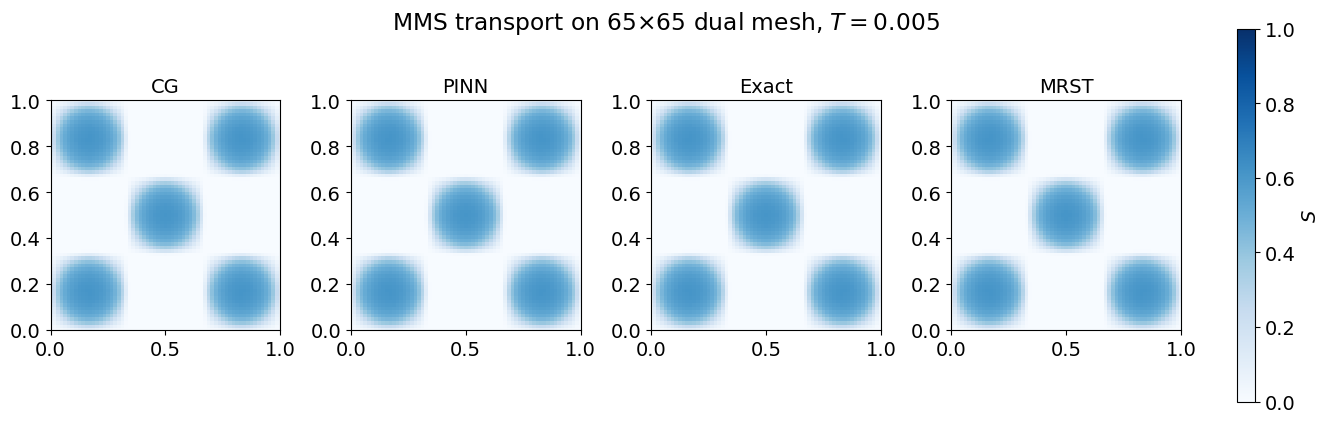

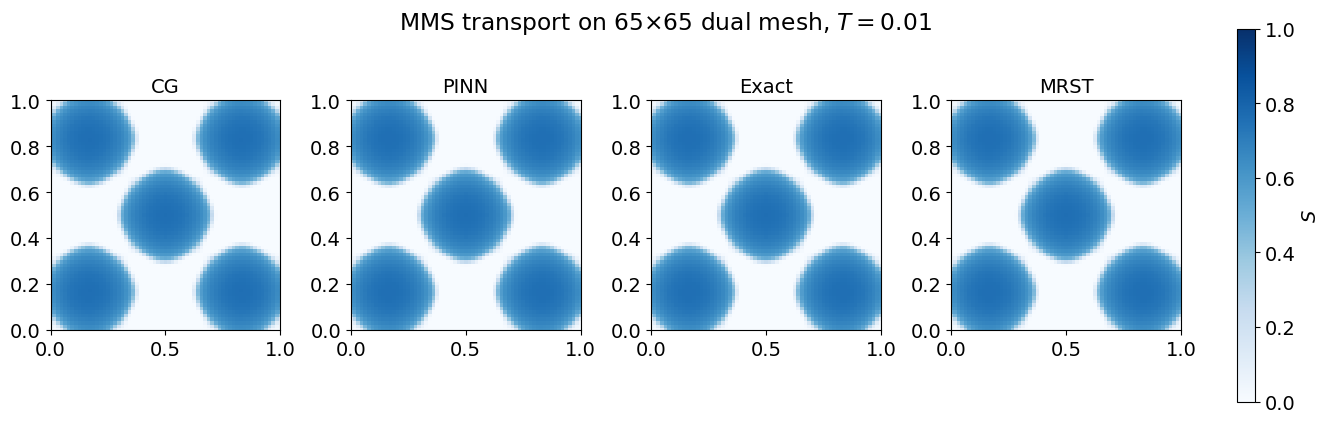

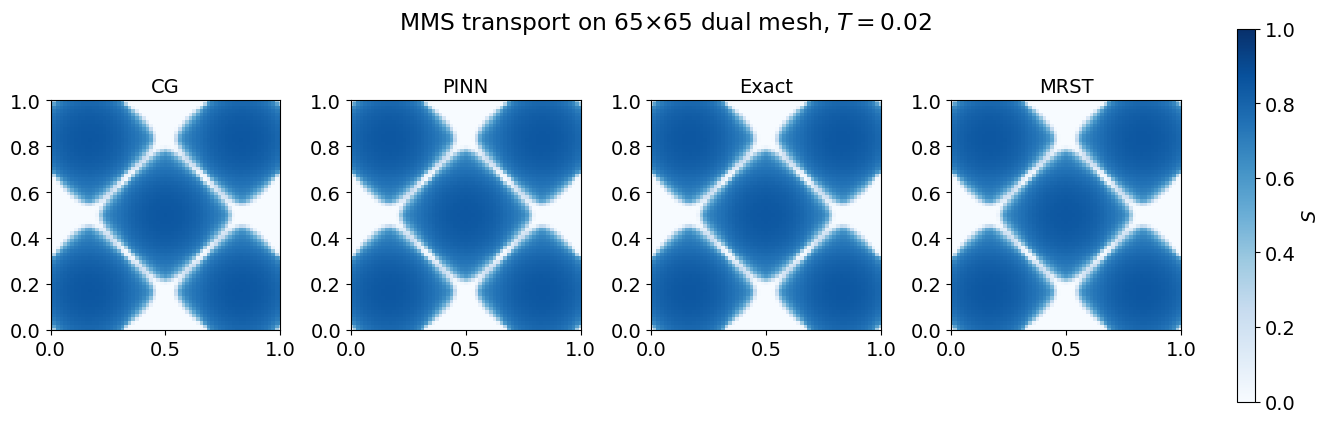

Saturation L2 errors relative to optional MRST MMS snapshots:
  time      method        L2 error       RMSE      max|e|
  0.005    CG        9.084509e-05 9.387820e-05 4.260785e-04
  0.005    PINN      3.478467e-04 3.477164e-04 2.677953e-03
  0.005    Exact     1.400229e-04 1.425602e-04 5.406854e-04
  0.01     CG        2.180188e-04 2.330094e-04 1.113472e-03
  0.01     PINN      1.314572e-03 1.325042e-03 1.518515e-02
  0.01     Exact     1.361230e-04 1.360179e-04 7.116108e-04
  0.02     CG        6.884701e-04 7.669170e-04 3.488796e-03
  0.02     PINN      2.249425e-03 2.341784e-03 3.089439e-02
  0.02     Exact     3.527715e-05 3.504843e-05 1.575210e-04


In [9]:
# Explicit upwind Buckley-Leverett transport on the 65 x 65 nodal-dual mesh.
# Positive f injects water at S=1; negative f removes resident fluid; boundary inflow has S=0.

def fractional_flow_bl(S):
    S = np.asarray(S, dtype=float)
    return S ** 2 / (S ** 2 + (1.0 - S) ** 2 + 1.0e-30)


def compute_transport_dt(Fout):
    outflow = np.zeros(n_nodes, dtype=float)
    np.add.at(outflow, dual_owner, np.maximum(Fout, 0.0))
    np.add.at(outflow, dual_neigh[dual_has_neighbor], np.maximum(-Fout[dual_has_neighbor], 0.0))
    outflow += np.abs(dual_source_rate)
    active = (outflow > 1.0e-30) & (dual_pv > 0.0)
    if not np.any(active):
        raise RuntimeError("No active transport CVs found.")
    return CFL * np.min(dual_pv[active] / (FPRIME_MAX * outflow[active]))


def source_water_rate(S):
    S = np.asarray(S, dtype=float)
    out = np.zeros_like(S)
    pos = dual_source_rate > 0.0
    neg = dual_source_rate < 0.0
    out[pos] = dual_source_rate[pos] * fractional_flow_bl(SOURCE_SATURATION)
    out[neg] = dual_source_rate[neg] * fractional_flow_bl(S[neg])
    return out


def advance_dual_transport(Fout, t_final, clip=True, nsteps_override=None):
    Fout = np.asarray(Fout, dtype=float).reshape(-1)
    dt_cfl = compute_transport_dt(Fout)
    if nsteps_override is None:
        nsteps = max(1, int(np.ceil(float(t_final) / (TRANSPORT_DT if TRANSPORT_USE_FIXED_DT else dt_cfl))))
        dt_source = "fixed dt" if TRANSPORT_USE_FIXED_DT else "method CFL"
    else:
        nsteps = max(1, int(nsteps_override))
        dt_source = "shared nsteps"
    dt = float(t_final) / nsteps
    dt_over_pv = np.zeros_like(dual_pv)
    active = dual_pv > 0.0
    dt_over_pv[active] = dt / dual_pv[active]

    outward = Fout >= 0.0
    incoming_boundary = (~outward) & dual_is_boundary
    up_cv = np.empty_like(dual_owner)
    up_cv[outward] = dual_owner[outward]
    interior_negative = (~outward) & dual_has_neighbor
    up_cv[interior_negative] = dual_neigh[interior_negative]
    up_cv[incoming_boundary] = dual_owner[incoming_boundary]
    boundary_water_flux = fractional_flow_bl(BOUNDARY_INFLOW_S) * Fout

    S = np.zeros(n_nodes, dtype=float)
    cumulative_in = 0.0
    cumulative_out = 0.0
    cumulative_source = 0.0
    preclip_min = 0.0
    preclip_max = 0.0
    clip_mass_delta = 0.0
    clipped_count = 0
    for _ in range(nsteps):
        water_flux = fractional_flow_bl(S[up_cv]) * Fout
        water_flux[incoming_boundary] = boundary_water_flux[incoming_boundary]
        wb = water_flux[dual_is_boundary]
        cumulative_in += dt * float(np.sum(np.maximum(-wb, 0.0)))
        cumulative_out += dt * float(np.sum(np.maximum(wb, 0.0)))
        div = np.zeros(n_nodes, dtype=float)
        np.add.at(div, dual_owner, water_flux)
        np.add.at(div, dual_neigh[dual_has_neighbor], -water_flux[dual_has_neighbor])
        sw = source_water_rate(S)
        cumulative_source += dt * float(np.sum(sw))
        S_new = S - dt_over_pv * (div - sw)
        preclip_min = min(preclip_min, float(np.min(S_new)))
        preclip_max = max(preclip_max, float(np.max(S_new)))
        if clip:
            S_clip = np.clip(S_new, 0.0, 1.0)
            clipped_count += int(np.count_nonzero(S_clip != S_new))
            clip_mass_delta += float(np.sum((S_clip - S_new) * dual_pv))
            S = S_clip
        else:
            S = S_new
    mass = float(np.sum(S * dual_pv))
    net = float(cumulative_in - cumulative_out + cumulative_source)
    denom = max(abs(cumulative_source) + cumulative_in, 1.0e-30)
    return S, {
        "T": float(t_final), "dt": float(dt), "dt_cfl": float(dt_cfl), "nsteps": int(nsteps), "dt_source": dt_source,
        "water_in": float(cumulative_in), "water_out": float(cumulative_out), "water_source": float(cumulative_source),
        "water_net": float(net), "water_mass": float(mass), "water_balance_error": float(mass - net),
        "water_balance_error_pct": float(100.0 * (mass - net) / denom),
        "preclip_min": float(preclip_min), "preclip_max": float(preclip_max), "clip_mass_delta": float(clip_mass_delta), "clipped_count": int(clipped_count),
    }

transport_cases = [(f"T{T:g}", float(T)) for T in TRANSPORT_T_VALUES]
transport_flux_methods = {"CG": dual_flux_by_method["CG"], "PINN": dual_flux_by_method["PINN"], "Exact": dual_flux_by_method["Exact"]}
reference_dt = min(compute_transport_dt(F) for F in transport_flux_methods.values())
reference_nsteps = {key: max(1, int(np.ceil(T / reference_dt))) for key, T in transport_cases}
transport_results = {}
for key, T in transport_cases:
    transport_results[key] = {}
    for name, Fout in transport_flux_methods.items():
        S, meta = advance_dual_transport(Fout, T, clip=TRANSPORT_CLIP, nsteps_override=reference_nsteps[key])
        transport_results[key][name] = {"S": S, "meta": meta}

print(f"Transport clipping enabled: {TRANSPORT_CLIP}, shared dt base={reference_dt:.6e}")
print("Transport diagnostics:")
print("  case    method  nsteps        dt       CFL dt    min(S)    max(S)  preclip min  preclip max    clip dM    balance%")
for key, T in transport_cases:
    for name in transport_flux_methods:
        item = transport_results[key][name]
        S = item["S"]
        meta = item["meta"]
        print(
            f"  {key:<7} {name:<6} {meta['nsteps']:7d} {meta['dt']:10.4e} {meta['dt_cfl']:10.4e} "
            f"{np.min(S):8.3e} {np.max(S):8.3e} {meta['preclip_min']:12.3e} {meta['preclip_max']:12.3e} "
            f"{meta['clip_mass_delta']:11.3e} {meta['water_balance_error_pct']:10.3e}"
        )

# Optional MRST MMS saturation comparison, if a matching file has been exported.
def _mms_time_token(T):
    return f"T{float(T):.3f}".replace(".", "p")


def snapshot_key_for_time(data, T, explicit=True):
    decimal_suffix = _mms_time_token(T)
    legacy_suffix = f"T{int(round(100.0 * float(T))):03d}"
    candidates = [
        f"sw_{decimal_suffix}",
        f"sw_{decimal_suffix}_exp",
        f"sw_{legacy_suffix}_exp",
        f"sw_{legacy_suffix}",
        f"sw_T{int(round(1000.0 * float(T))):03d}",
    ]
    if not explicit:
        candidates = [candidates[0], candidates[2], candidates[1], candidates[3], candidates[4]]
    for key in candidates:
        if key in data:
            return key
    if "snap_times" in data:
        times = np.asarray(data["snap_times"], dtype=float).reshape(-1)
        if times.size:
            idx = int(np.argmin(np.abs(times - float(T))))
            if abs(times[idx] - float(T)) < 1.0e-8:
                return snapshot_key_for_time(data, float(times[idx]), explicit=explicit)
    return None

mrst_mms_candidates = [
    folder / f"mms_k{int(MMS_K)}_mrst_export_finep_dualT.mat",
    folder / f"case3_mrst_export_mms_k{int(MMS_K)}.mat",
    folder / f"case3_mrst_export_sin_kpi_mms_k{int(MMS_K)}.mat",
    folder / f"case3_mrst_export_mms_sin_k{int(MMS_K)}.mat",
]
MRST_MMS_FILE = next((p for p in mrst_mms_candidates if p.exists()), None)
mrst_mms_by_time = {}
if MRST_MMS_FILE is not None:
    data = loadmat(MRST_MMS_FILE, squeeze_me=True, struct_as_record=False)
    for key, T in transport_cases:
        skey = snapshot_key_for_time(data, T, explicit=True)
        if skey is not None:
            arr = np.asarray(data[skey], dtype=float).reshape(-1)
            if arr.size == n_nodes:
                mrst_mms_by_time[key] = arr.reshape(dual_shape)
            elif arr.size == ncell:
                mrst_mms_by_time[key] = arr.reshape(NY, NX)
            else:
                print(f"MRST MMS snapshot {skey} has unsupported size {arr.size}; expected {n_nodes} or {ncell}.")
    print(f"Loaded optional MRST MMS comparison: {MRST_MMS_FILE.name}, snapshots={list(mrst_mms_by_time)}")
else:
    print("Optional MRST MMS file not found; saturation comparison is CG/PINN/exact only.")

with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    for key, T in transport_cases:
        panels = [("CG", transport_results[key]["CG"]["S"].reshape(dual_shape), x_dual_edges, y_dual_edges),
                  ("PINN", transport_results[key]["PINN"]["S"].reshape(dual_shape), x_dual_edges, y_dual_edges),
                  ("Exact", transport_results[key]["Exact"]["S"].reshape(dual_shape), x_dual_edges, y_dual_edges)]
        if key in mrst_mms_by_time:
            G = mrst_mms_by_time[key]
            if G.shape == dual_shape:
                panels.append(("MRST", G, x_dual_edges, y_dual_edges))
            else:
                panels.append(("MRST", G, x_edges, y_edges))
        fig, axes = plt.subplots(1, len(panels), figsize=(3.3 * len(panels), 4.0), squeeze=False, constrained_layout=True)
        axes = axes[0]
        pcm = None
        for ax, (title, grid, xe, ye) in zip(axes, panels):
            pcm = ax.pcolormesh(xe, ye, grid, cmap="Blues", vmin=0.0, vmax=1.0, shading="flat")
            ax.set_aspect("equal")
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)
            ax.set_title(title)
            ax.grid(False)
        cbar = fig.colorbar(pcm, ax=axes.ravel().tolist(), fraction=0.046, pad=0.03)
        cbar.set_label(r"$S$")
        fig.suptitle(rf"MMS transport on 65$\times$65 dual mesh, $T={T:g}$", y=1.02)
        plt.show()

if mrst_mms_by_time:
    area_dual = np.outer(np.diff(y_dual_edges), np.diff(x_dual_edges)).reshape(-1)
    print("Saturation L2 errors relative to optional MRST MMS snapshots:")
    print("  time      method        L2 error       RMSE      max|e|")
    for key, T in transport_cases:
        if key not in mrst_mms_by_time or mrst_mms_by_time[key].shape != dual_shape:
            continue
        ref = mrst_mms_by_time[key].reshape(-1)
        for name in ["CG", "PINN", "Exact"]:
            diff = transport_results[key][name]["S"] - ref
            print(f"  {T:<8.4g} {name:<8} {np.sqrt(np.sum(diff ** 2 * area_dual)):13.6e} {np.sqrt(np.mean(diff ** 2)):10.6e} {np.max(np.abs(diff)):10.6e}")

